# Вовлечённость участников клуба «МОЖНО»

Ноутбук пересчитывает метрики за 7, 30, 90 дней и весь доступный период, строит когорты и проверяет ранние факторы возврата. Пассивные просмотры Telegram недоступны, поэтому под активностью понимаются сообщения, ответы и реакции.

Отмена подписки, выход из группы и снижение активности анализируются раздельно.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

analysis_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(analysis_root)
sys.path.insert(0, str(analysis_root))
from src.engagement_analysis import run_analysis

result = run_analysis()
summary = result['summary']
summary

{'as_of': '2026-08-01T13:27:39+00:00',
 'message_period_start': '2026-01-11T06:17:14+00:00',
 'message_period_end': '2026-08-01T13:08:59+00:00',
 'messages_total': 25718,
 'known_people': 166,
 'telegram_member_count_including_bots': 107,
 'confirmed_current_humans': 103,
 'confirmed_left_humans': 12,
 'unconfirmed_status_humans': 51,
 'active_people': {'7d': 56, '30d': 76, '90d': 103, 'all': 151},
 'messages': {'7d': 812, '30d': 4260, '90d': 10324, 'all': 25349},
 'visits': {'7d': 0, '30d': 0, '90d': 0, 'all': 0},
 'top_10_percent_message_share': 0.6284,
 'message_gini': 0.7664,
 'active_people_trend_last_4_full_weeks_pct': -12.7,
 'messages_trend_last_4_full_weeks_pct': 53.3,
 'factor_comparisons': [{'factor': 'Первый ответ получен не позднее 24 часов',
   'with_factor_n': 59,
   'with_factor_return_rate': 0.7288135593220338,
   'without_factor_n': 57,
   'without_factor_return_rate': 0.5614035087719298,
   'difference_pp': 16.741005055010405,
   'fisher_p_value': 0.08030240233952146

## Краткий отчёт

In [2]:
display(Markdown(Path('outputs/insights.md').read_text(encoding='utf-8')))

# Вовлечённость участников клуба «МОЖНО»

Срез данных: **01.08.2026 18:27 YEKT**.

## Что измерено

- Сообщения: 25,718 записей с 11.01.2026.
- Подтверждённые текущие участники без ботов: 103 из 107 аккаунтов в Telegram-группе.
- Подтверждённо вышли: 12; ещё у 51 известных аккаунтов Telegram API не подтвердил текущий статус — они не считаются добровольно ушедшими.
- Реакции доступны с 04.06.2026; события вступления и выхода — с 04.06.2026.
- Известно, что часть людей отменила платную подписку, но список отмен пока не загружен. Такие случаи нельзя автоматически считать уходом из-за невовлечённости.
- Пассивные открытия и чтение Telegram-группы недоступны. Вместо «посещений» используются активные дни и недели.

## Активность по временным окнам

| Окно | Писали, человек | Сообщений |
|---|---:|---:|
| 7 дней | 56 | 812 |
| 30 дней | 76 | 4,260 |
| 90 дней | 103 | 10,324 |
| Весь период | 151 | 25,349 |

Посещения встреч не посчитаны: файл `data/attendance.csv` пока отсутствует.

## Предварительные инсайты

1. **Активность сконцентрирована:** верхние 10% пишущих создали 62.8% сообщений; коэффициент Джини — 0.77. Это показывает зависимость клуба от активного ядра, но само по себе не доказывает проблему.
2. **Последние четыре полные недели:** среднее число активных авторов изменилось на -12.7%, объём сообщений — на +53.3% относительно предыдущих четырёх недель.
3. **Первый ответ получен не позднее 24 часов:** возврат на 30–60-й день — 72.9% (n=59) против 56.1% (n=57), разница +16.7 п.п.; связь заметна, на этом размере выборки статистически не подтверждено.
4. **Не менее двух собеседников за первые 30 дней:** возврат на 30–60-й день — 73.0% (n=100) против 12.5% (n=16), разница +60.5 п.п.; связь заметна, статистически различимо на этом срезе.
5. **Активность минимум в двух темах за первые 30 дней:** возврат на 30–60-й день — 75.0% (n=96) против 15.0% (n=20), разница +60.0 п.п.; связь заметна, статистически различимо на этом срезе.

## Текущие и подтверждённо вышедшие

В сравнение попали 65 текущих и 8 подтверждённо вышедших участников, у которых можно наблюдать первые 60 дней после первого сообщения.

- Первый ответ за 24 часа: текущие — 46.2%, вышедшие — 50.0%.
- Медиана собеседников за первые 30 дней: текущие — 11.0, вышедшие — 5.5.
- Медиана тем за первые 30 дней: текущие — 6.0, вышедшие — 3.0.

Это описательное сравнение небольшой группы. Без списка отмен подписки и объяснений самих людей оно не отвечает на вопрос о причине ухода.

## Сегменты текущих участников

- Регулярно активен: 48
- Активное ядро: 15
- Эпизодически активен: 13
- Неактивен 30–90 дней: 12
- Без сообщений: 9
- Неактивен 90+ дней: 6

## Как читать результаты

- Найденные различия — корреляции, а не доказанные причины.
- Возврат измеряется сообщением на 30–60-й день после первого сообщения, а не чтением чата.
- Владелец и администраторы учитываются в динамике клуба, но исключены из сравнения обычных участников.
- Статусы `API_ERROR` не приравнены к выходу: Telegram не подтвердил их текущее состояние.
- Отмена платной подписки, выход из Telegram-группы и снижение активности рассматриваются как три разных события.
- Чтобы понять причины ухода, нужны короткий вопрос при выходе и разговоры с активными, неактивными и ушедшими.

## Чего пока не хватает

- посещений офлайн-встреч или других клубных мероприятий;
- пассивных просмотров Telegram — Telegram их не отдаёт;
- причин выхода, сообщённых самим участником;
- списка отмен платной подписки с Telegram ID и датой отмены;
- полной истории членства до 4 июня 2026 года.


## Динамика и структура активности

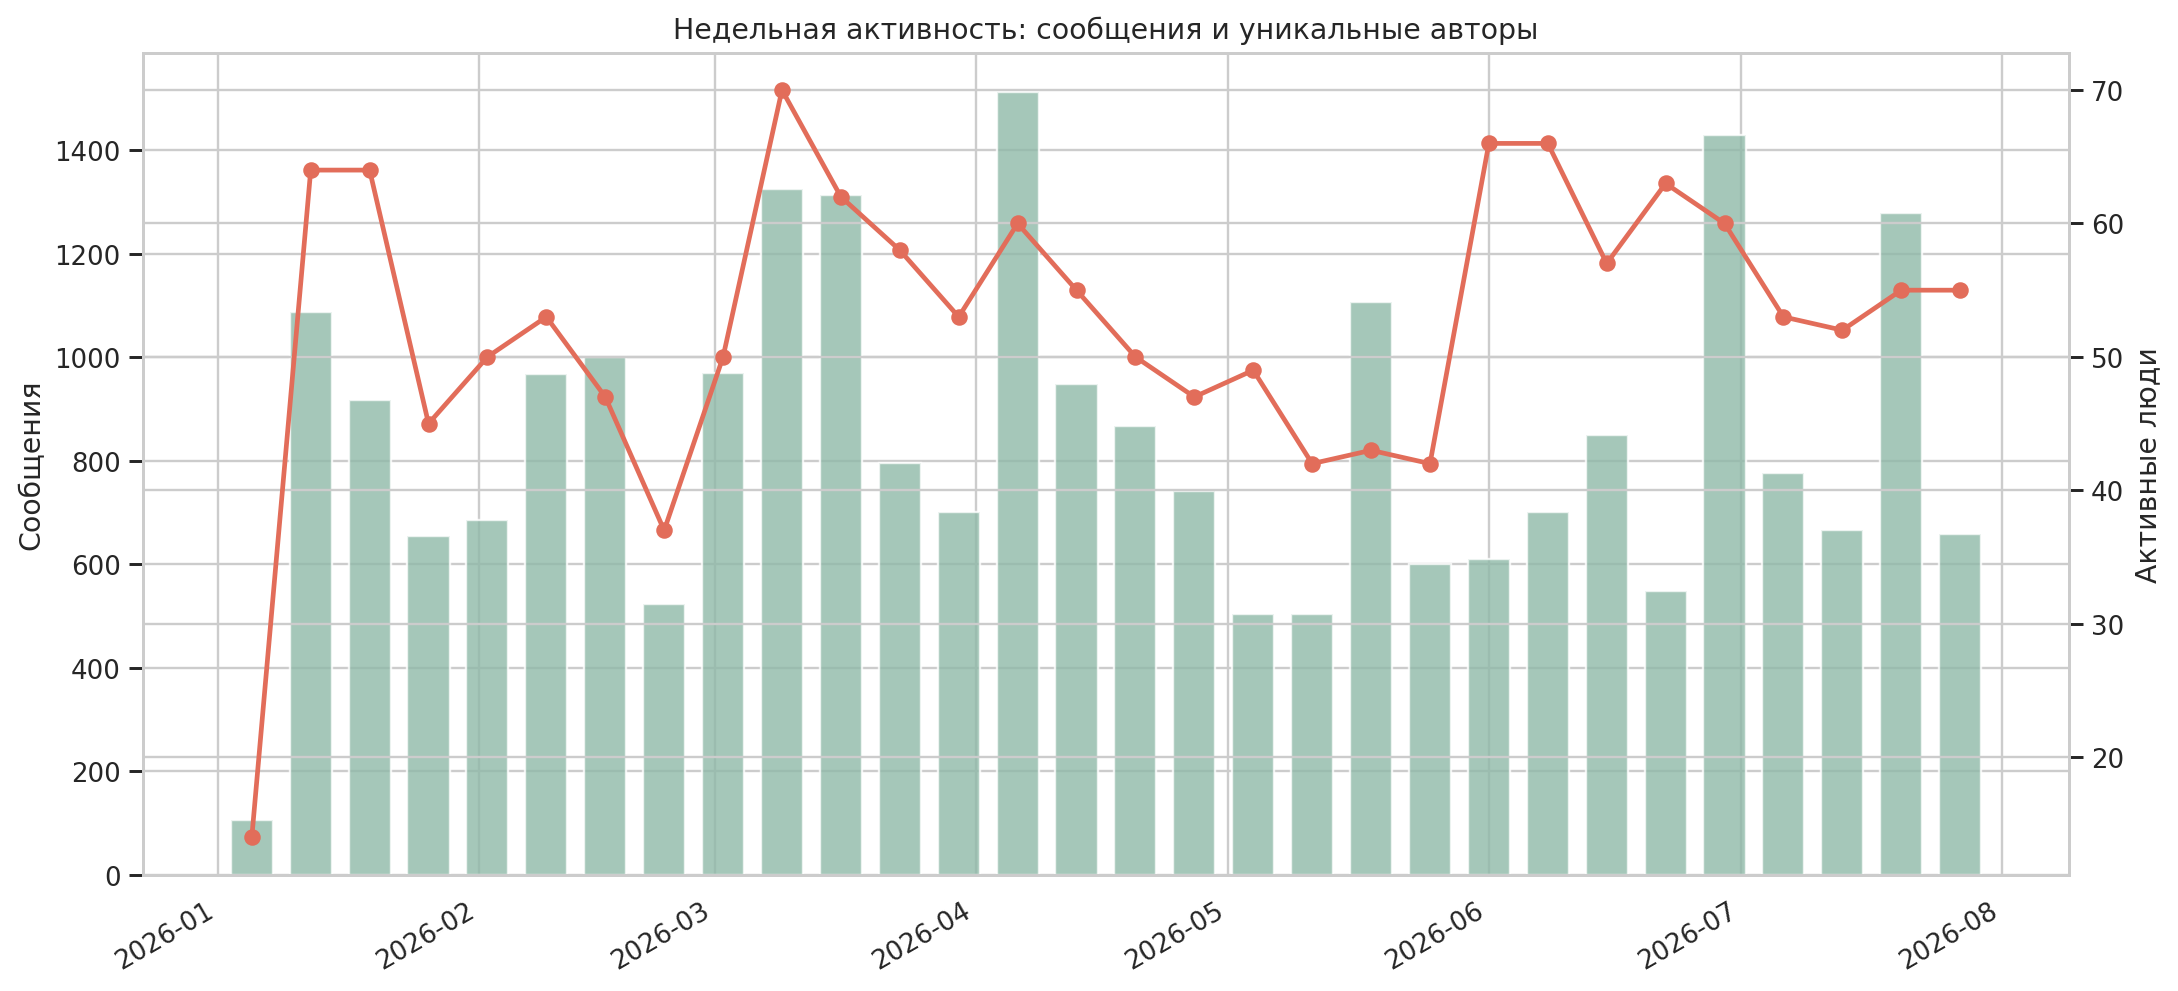

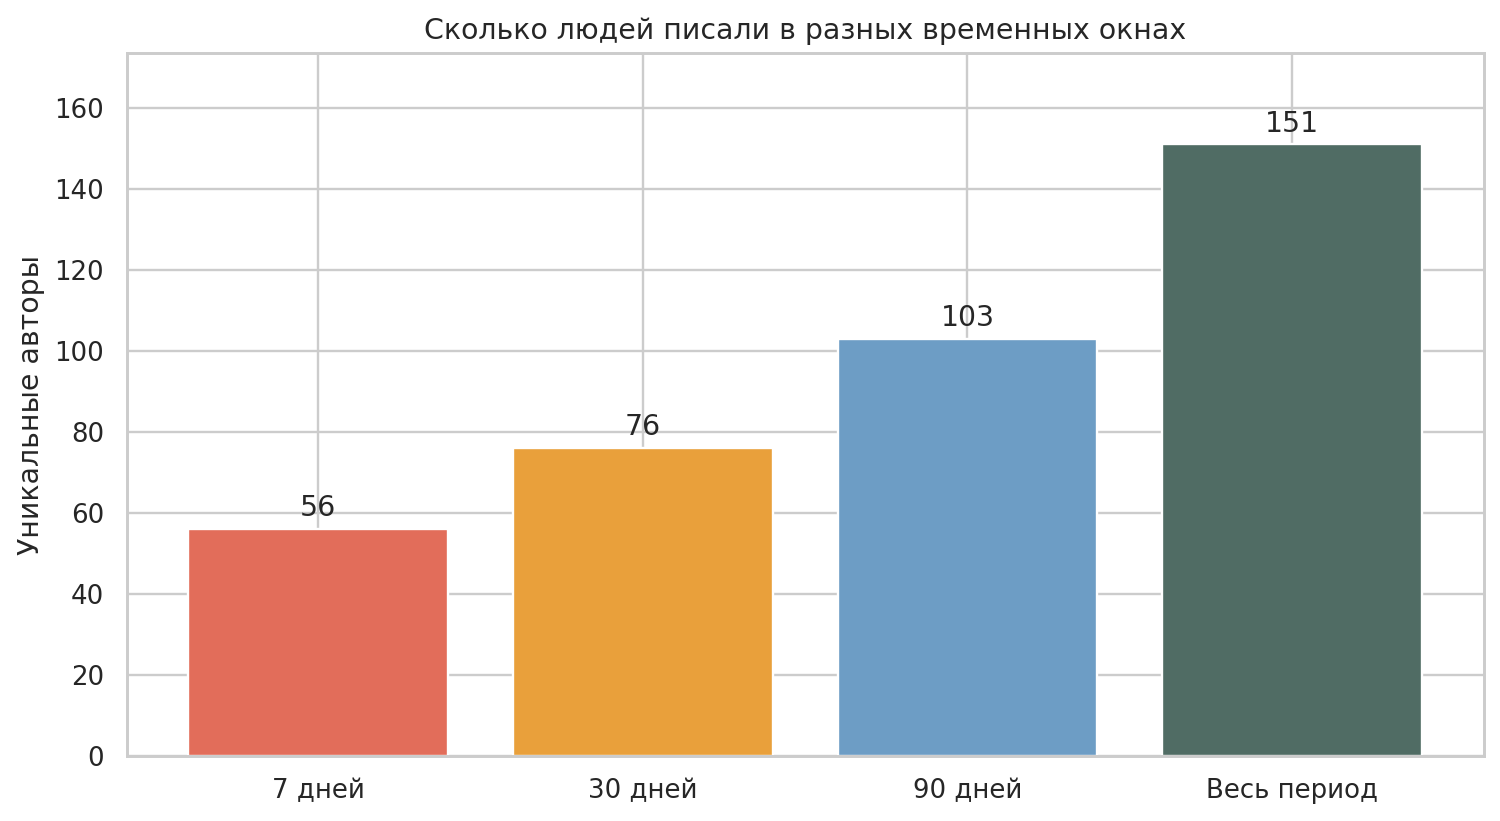

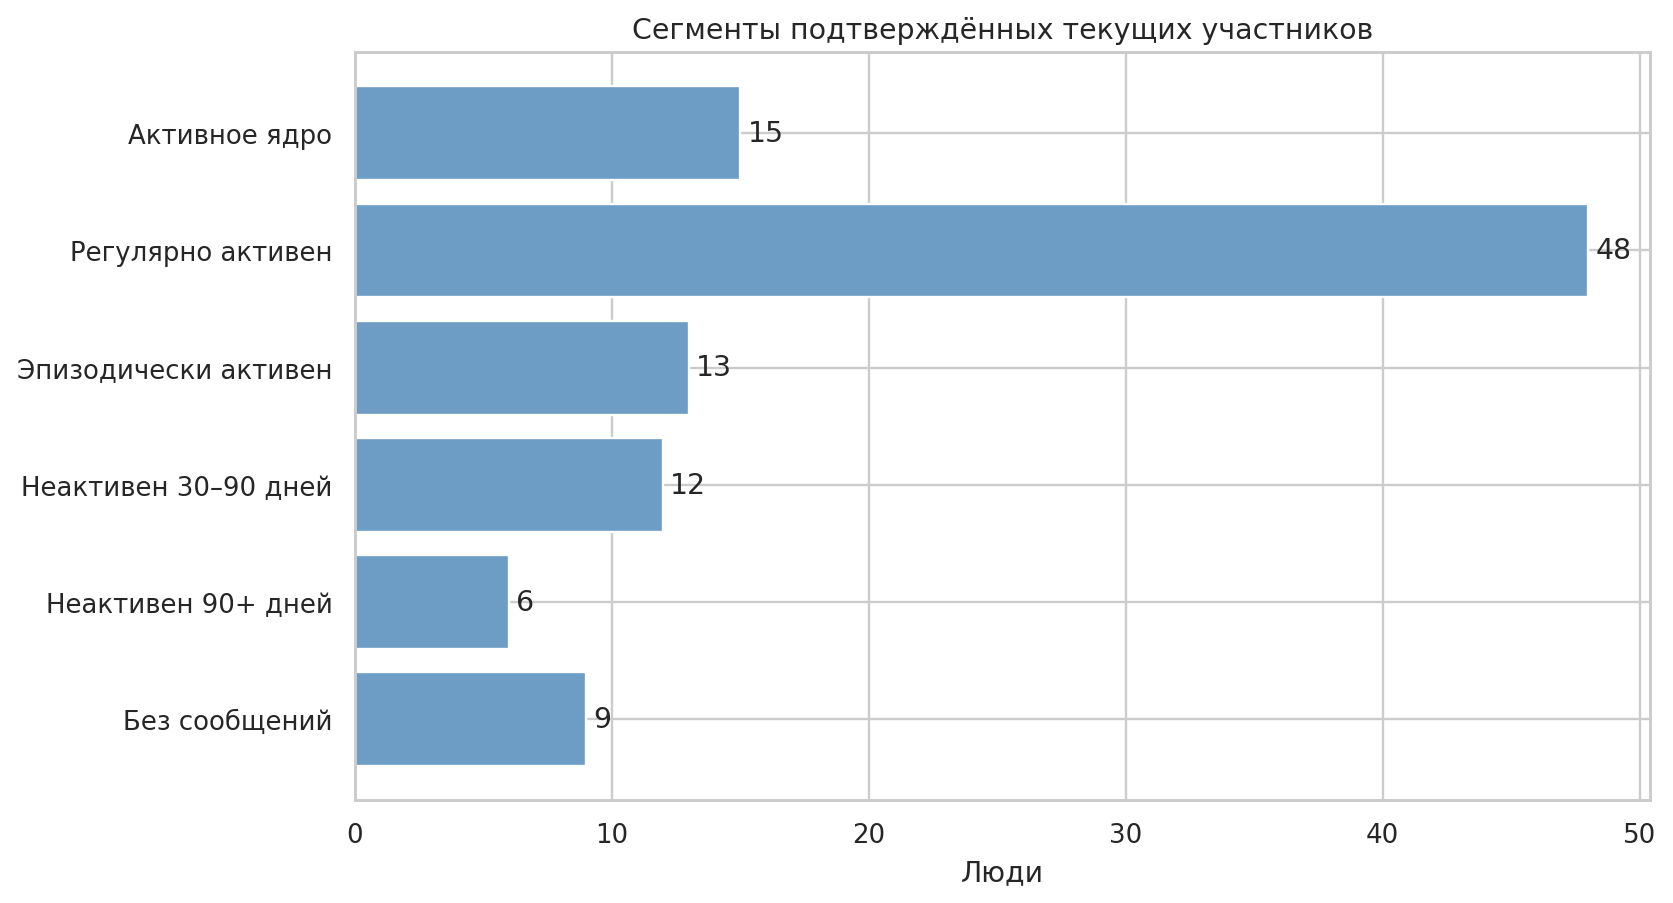

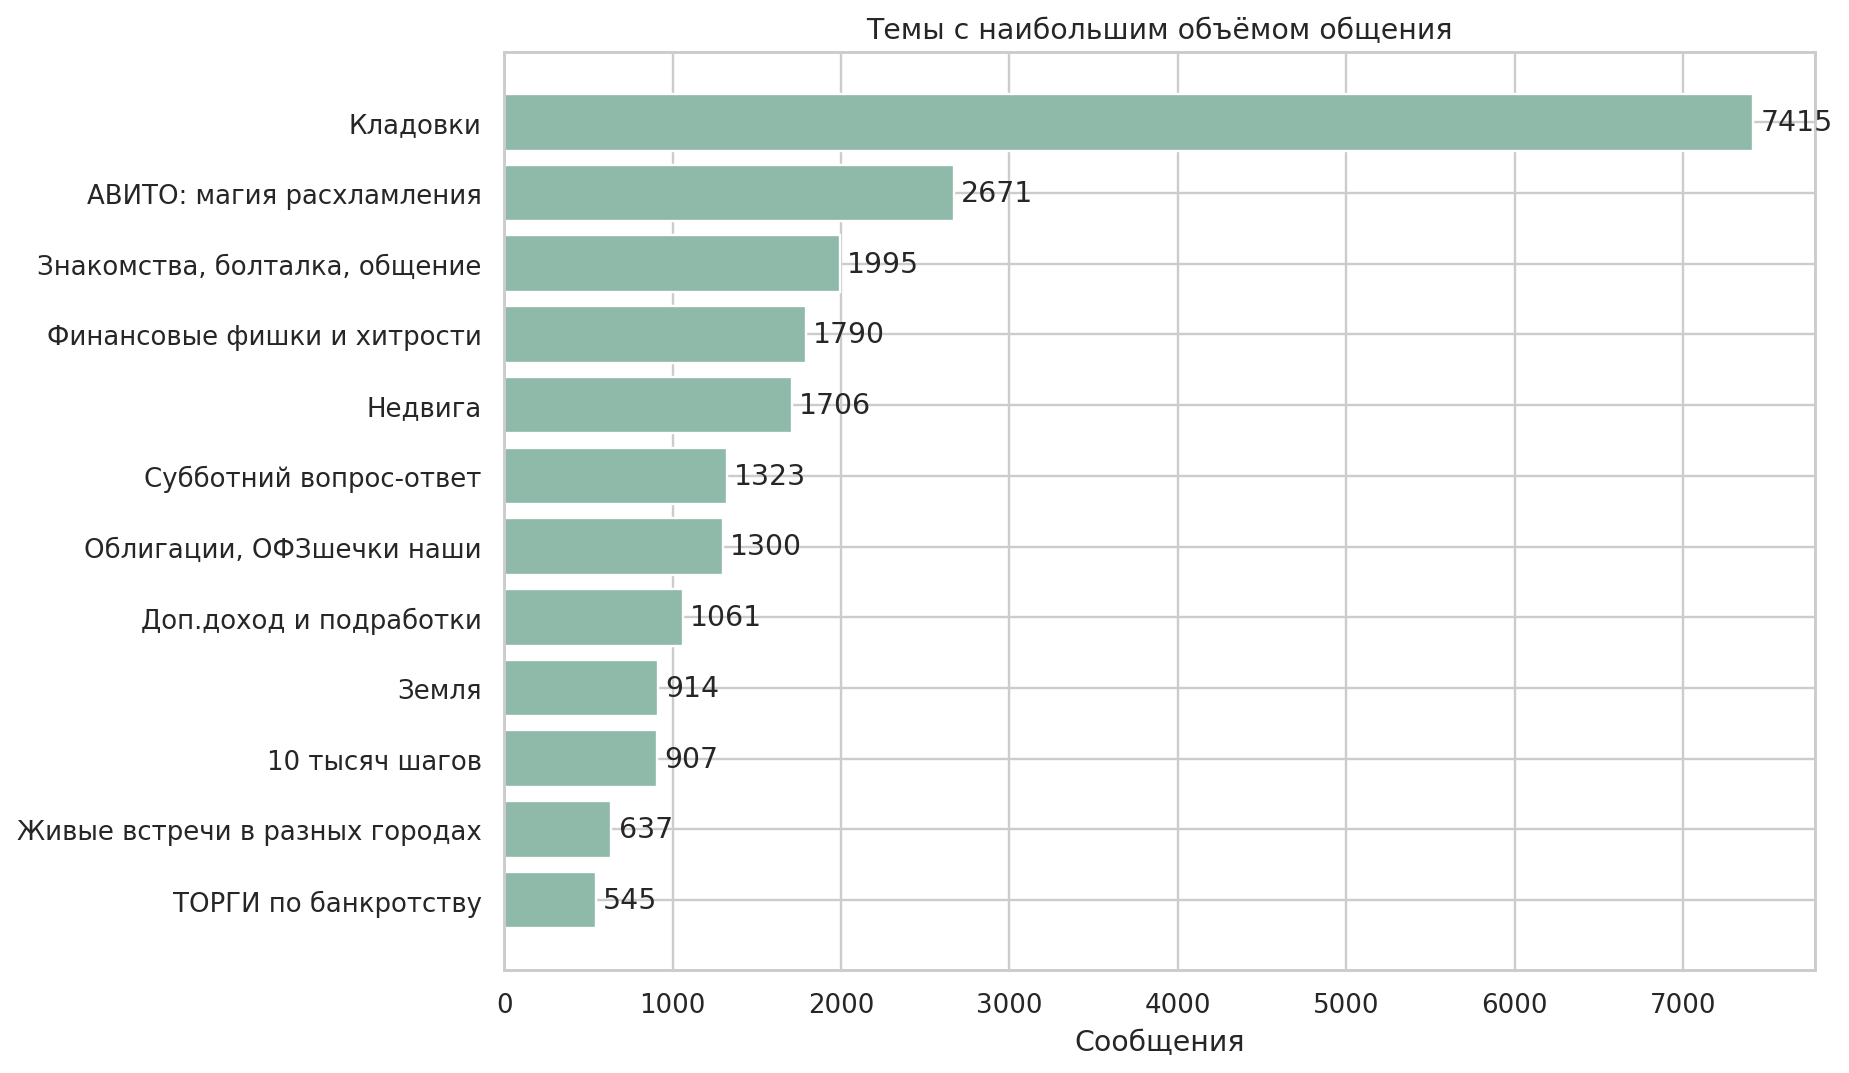

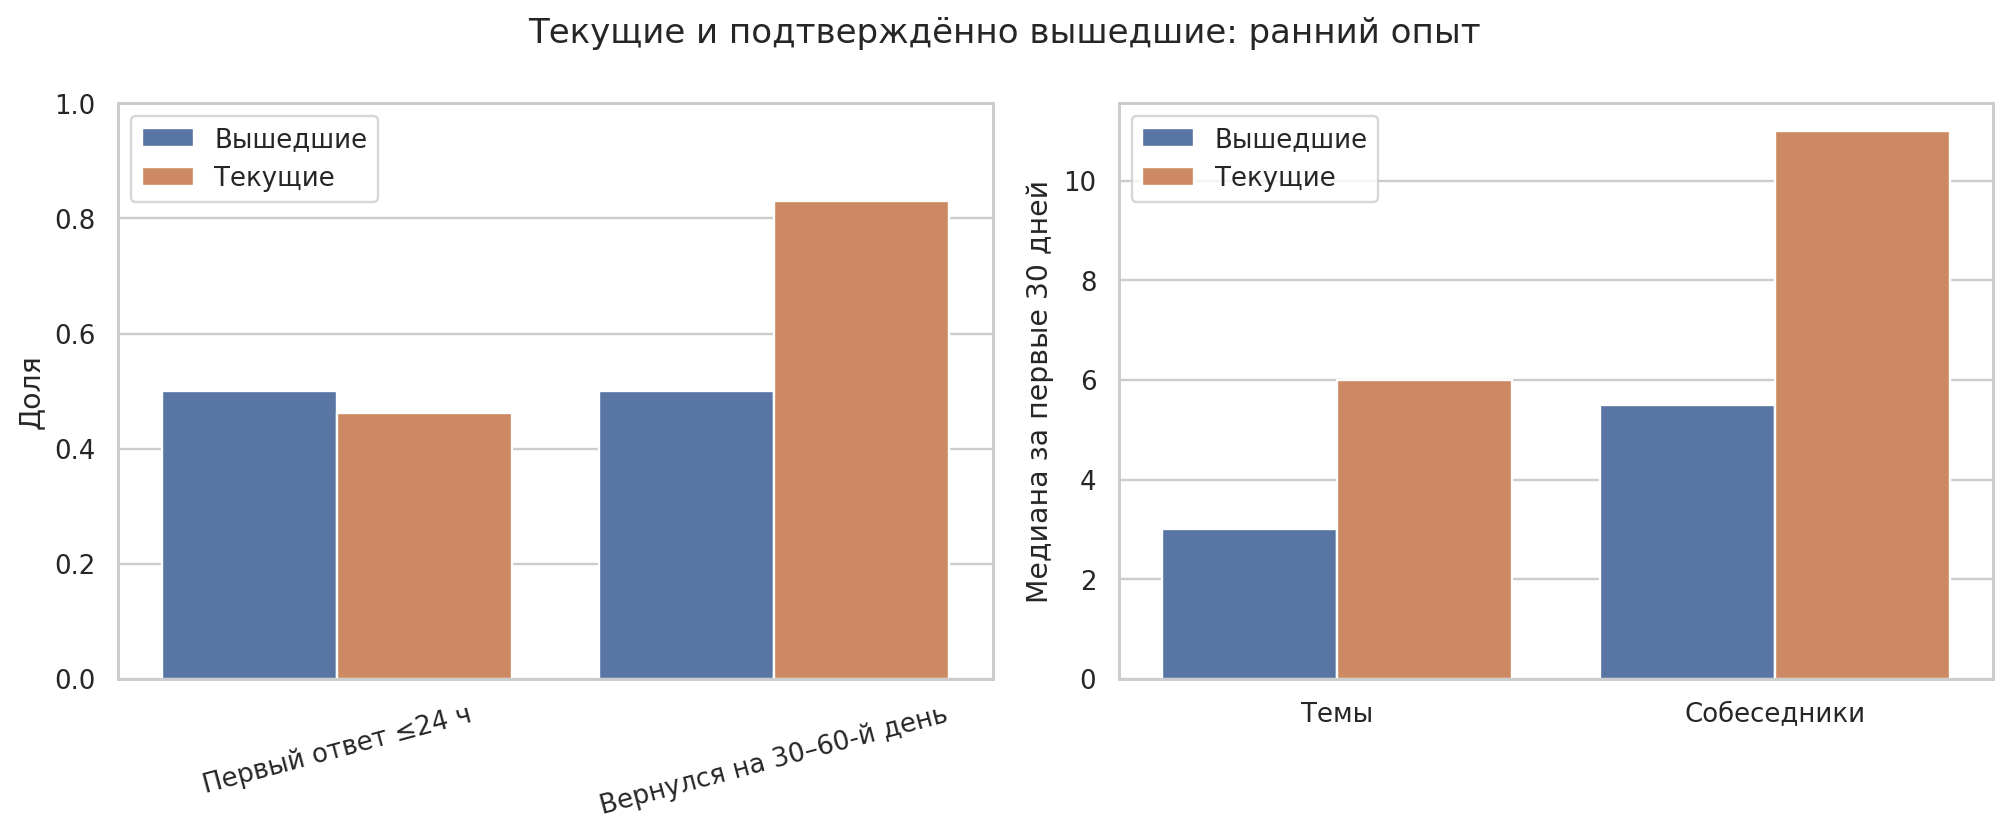

In [3]:
for filename in [
    'weekly_activity.png',
    'active_people_windows.png',
    'current_member_segments.png',
    'top_topics.png',
    'current_vs_left.png',
]:
    display(Image(filename=f'outputs/figures/{filename}'))

## Удержание и ранние факторы

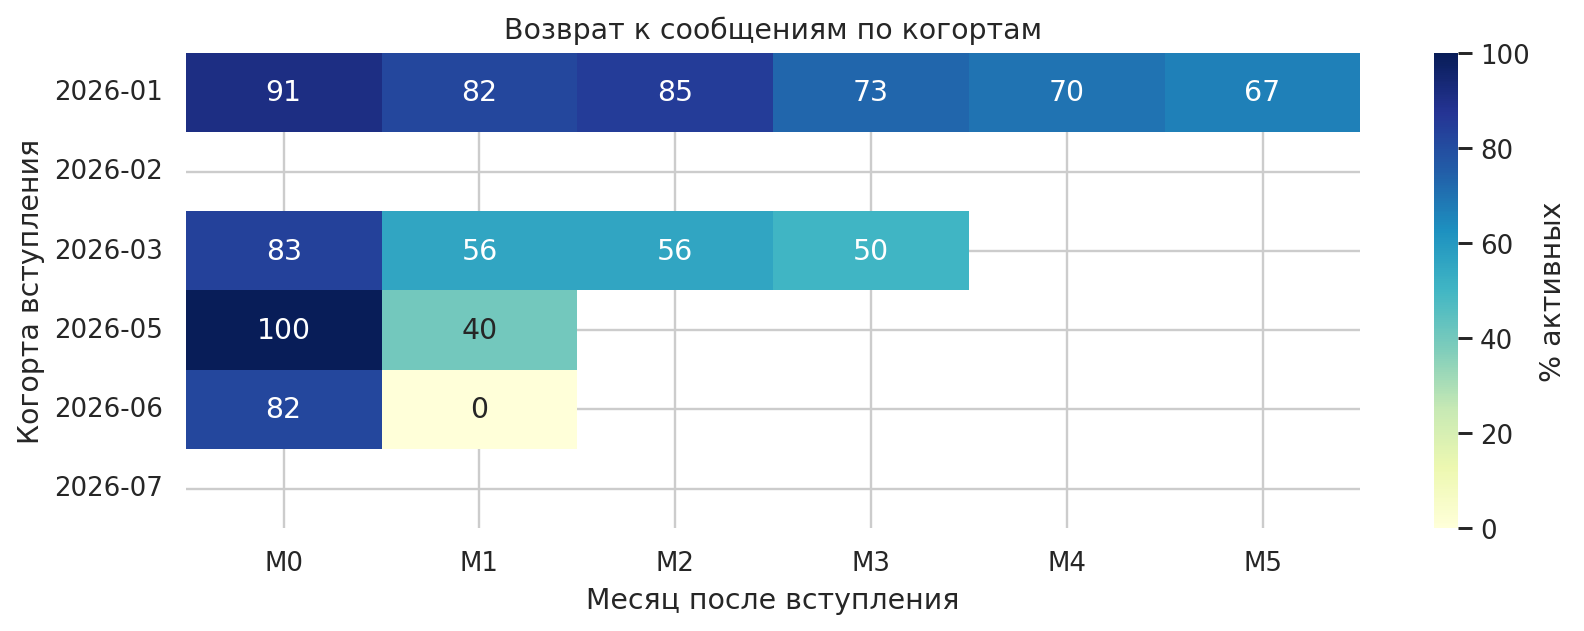

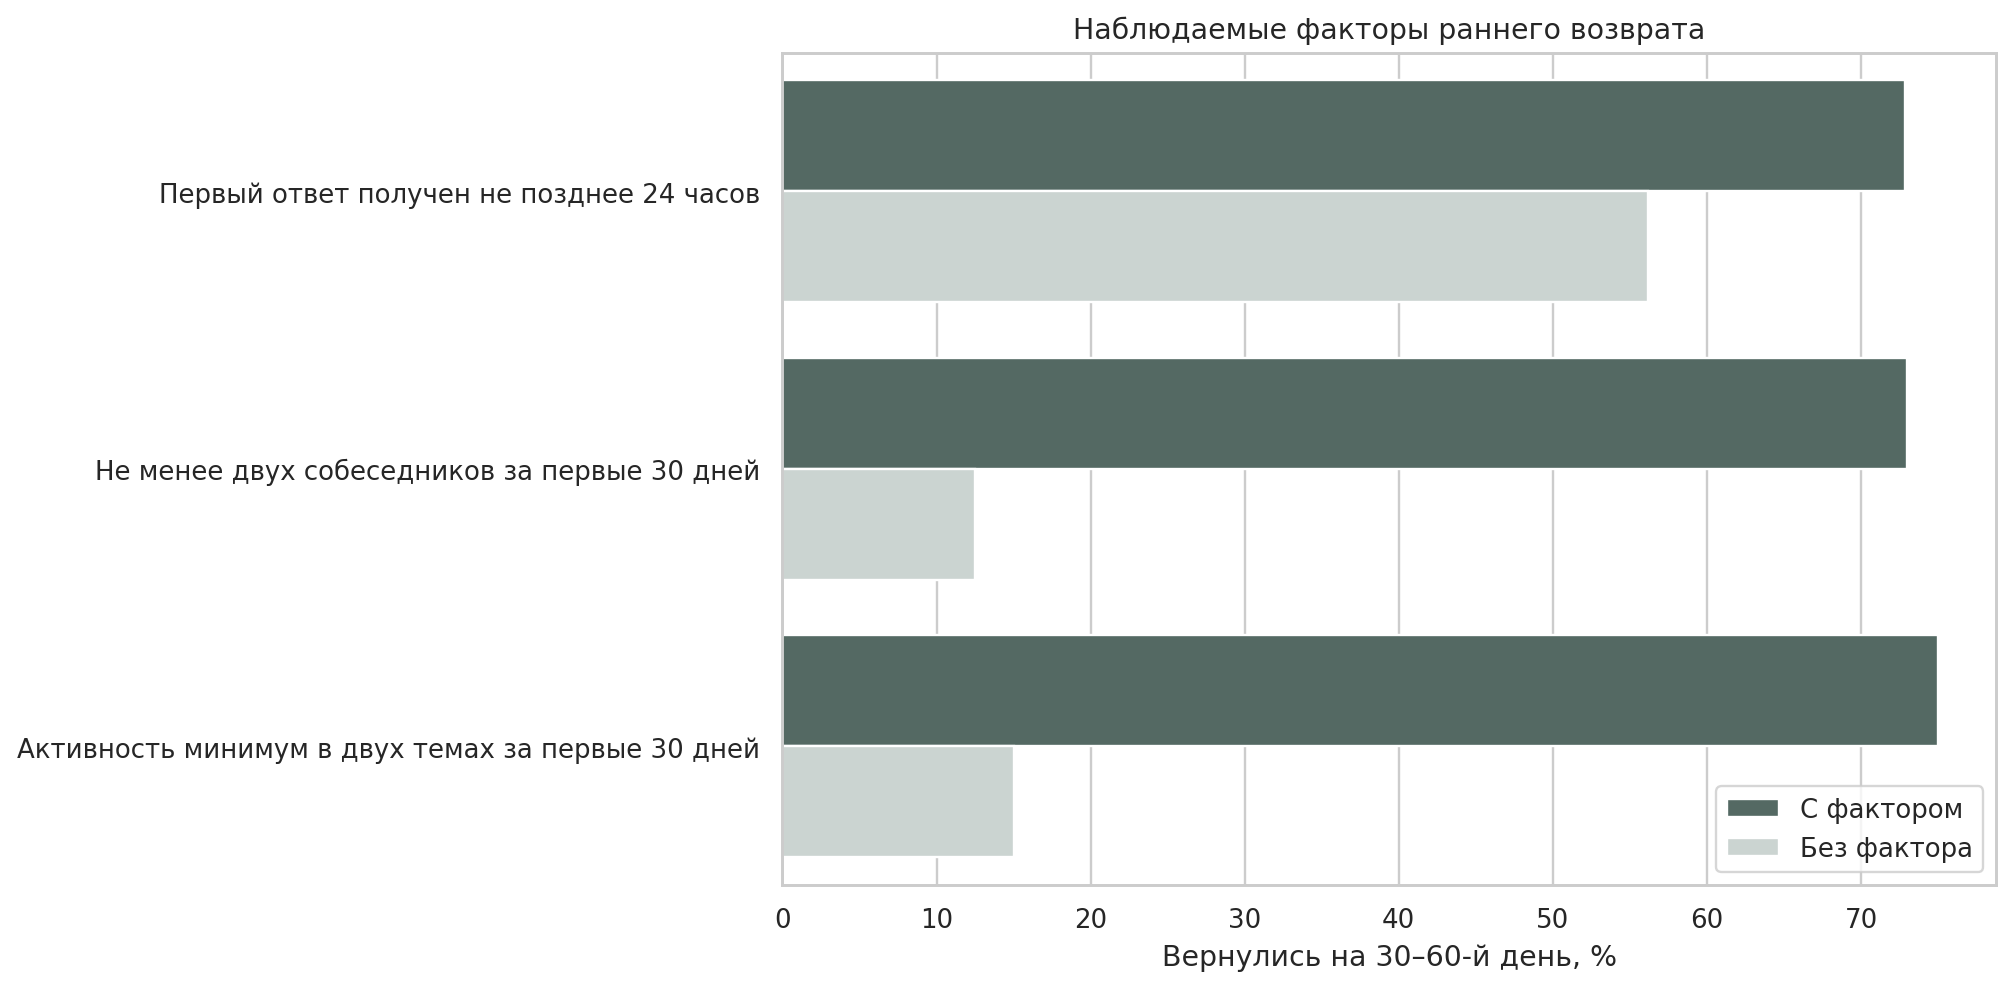

,factor,with_factor_n,with_factor_return_rate,without_factor_n,without_factor_return_rate,difference_pp,fisher_p_value
0,Первый ответ получен не позднее 24 часов,59,72.9%,57,56.1%,+16.7,0.0803
1,Не менее двух собеседников за первые 30 дней,100,73.0%,16,12.5%,+60.5,0.0000
2,Активность минимум в двух темах за первые 30 дней,96,75.0%,20,15.0%,+60.0,0.0000


In [4]:
display(Image(filename='outputs/figures/cohort_retention.png'))
display(Image(filename='outputs/figures/early_retention_factors.png'))
comparisons = pd.read_csv('outputs/tables/retention_factor_comparisons.csv')
comparisons.style.format({
    'with_factor_return_rate': '{:.1%}',
    'without_factor_return_rate': '{:.1%}',
    'difference_pp': '{:+.1f}',
    'fisher_p_value': '{:.4f}',
})

## Ограничения

- Telegram не отдаёт пассивные просмотры и время чтения группы.
- Реакции и события членства имеют более короткую историю, чем сообщения.
- Статус, который Telegram API не подтвердил, не считается добровольным выходом.
- Список отмен подписки подключается отдельно и не подменяется статусом в группе.
- Найденные различия показывают связь, а не доказанную причину.